In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [43]:

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [44]:
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

In [45]:
test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)

In [46]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names=train_data.target_names

In [47]:
print("Training docuents:",len(X_train_text))
print("Testing documents:", len(X_test_text))
print("Number of classes:",len(class_names))

Training docuents: 11314
Testing documents: 7532
Number of classes: 20


In [48]:
vectorizer= CountVectorizer(
    stop_words="english",
    min_df=2
)
X_train=vectorizer.fit_transform(X_train_text)
X_test= vectorizer.transform(X_test_text)

In [49]:
print("Training feature matrix:",X_train.shape)
print("Testing feature matrix:",X_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [50]:
mnb = MultinomialNB()

mnb.fit(
    X_train,
    y_train
)
y_pred_mnb= mnb.predict(X_test)

In [51]:
binary_vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary=binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary=binary_vectorizer.transform(
    X_test_text
)

In [52]:
bnb= BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb=bnb.predict(
    X_test_binary
)

In [55]:
results=pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
])

models=[
    ("MNB", mnb, y_pred_mnb),
    ("BNB", bnb, y_pred_bnb)
]

for name, model, pred in models:
    results.loc[len(results)]=[
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred,average='weighted'),
        recall_score(y_test, pred,average='weighted'),
        f1_score(y_test, pred,average='weighted'),
    ]
print(results)

  Model  Accuracy  Precision    Recall  F1 Score
0   MNB  0.651089   0.642532  0.651089  0.629644
1   BNB  0.485130   0.627034  0.485130  0.480839


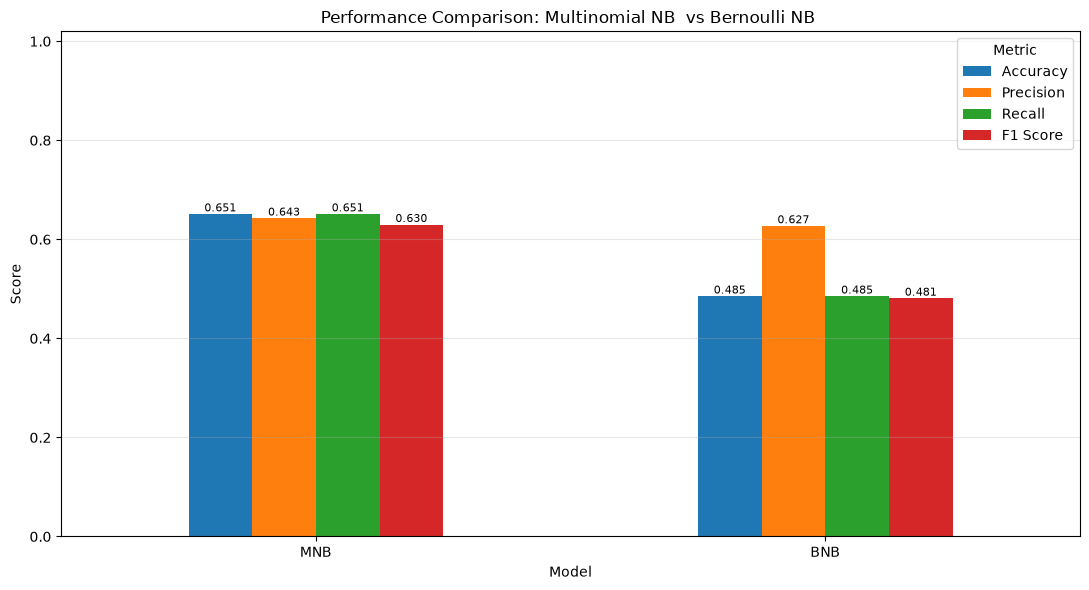

In [60]:

results_metrics = results[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
]
ax = results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11, 6)
)
plt.title("Performance Comparison: Multinomial NB  vs Bernoulli NB ")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)
plt.tight_layout()
plt.show()